In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


# Exploratory Data Analysis (EDA)

This notebook performs comprehensive analysis on the cleaned HR Employee Attrition dataset, including:
- Basic data exploration and attrition overview
- Employee satisfaction analysis by department, work mode, and location
- VADER sentiment analysis and sentiment-attrition relationships
- Workforce trends (overtime, workload, remote work patterns)
- Summary insights and recommendations

# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the HR Employee Attrition dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display basic statistics
print(df.describe())
print("\nData Info:")
print(df.info())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

## Step 1: Load Cleaned Data

In [17]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

print("="*80)
print("DATA LOADING & OVERVIEW")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"Total employees: {len(df)}")
print(f"\nColumn names ({df.shape[1]} total):")
print(df.columns.tolist()[:20])

print(f"\nFirst few rows:")
print(df.head())

print(f"\nData info:")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATA LOADING & OVERVIEW

Dataset shape: (1470, 78)
Total employees: 1470

Column names (78 total):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears']

First few rows:
   Age  DailyRate  DistanceFromHome  Education  EmployeeCount  EmployeeNumber  \
0   41       1102                 1          2              1               1   
1   49        279                 8          1              1               2   
2   37       1373                 2          2              1               4   
3   33       1392                 3          4              1               5   
4   27        591                 2          1              1               7   

   EnvironmentSatisfaction  HourlyRa

## Step 2: Basic EDA & Attrition Overview

BASIC EDA & ATTRITION OVERVIEW

Attrition Distribution:
Attrition_No
True     1233
False     237
Name: count, dtype: int64

Attrition Rate: 0.00%


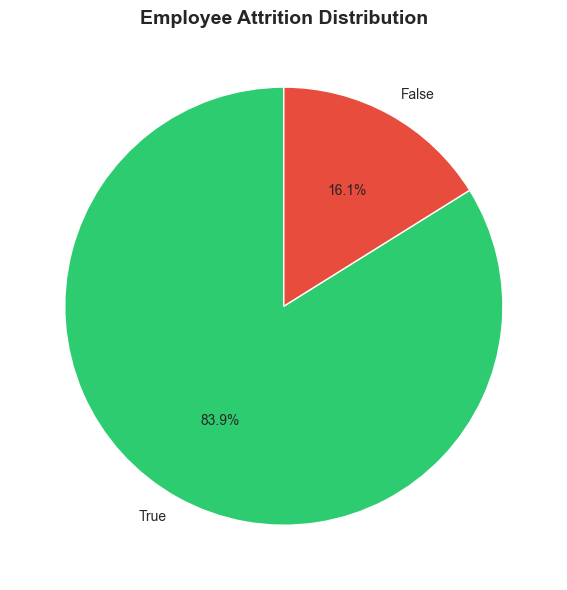


Satisfaction Index Statistics:
count    1470.000000
mean        2.730952
std         0.505815
min         1.000000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: satisfaction_index, dtype: float64

Attrition Risk Categories:
attrition_risk_category
Low_Risk       882
Medium_Risk    586
High_Risk        2
Name: count, dtype: int64


In [4]:
print("="*80)
print("BASIC EDA & ATTRITION OVERVIEW")
print("="*80)

# Attrition analysis
attrition_col = [col for col in df.columns if 'Attrition' in col][0] if any('Attrition' in col for col in df.columns) else None

if attrition_col:
    attrition_counts = df[attrition_col].value_counts()
    print(f"\nAttrition Distribution:")
    print(attrition_counts)
    print(f"\nAttrition Rate: {(attrition_counts.get('Yes', 0) / len(df) * 100):.2f}%")
    
    # Create pie chart
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    colors = ['#2ecc71', '#e74c3c']
    ax.pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%', 
           colors=colors, startangle=90)
    ax.set_title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Satisfaction index stats
if 'satisfaction_index' in df.columns:
    print(f"\nSatisfaction Index Statistics:")
    print(df['satisfaction_index'].describe())

# Risk category distribution
if 'attrition_risk_category' in df.columns:
    print(f"\nAttrition Risk Categories:")
    print(df['attrition_risk_category'].value_counts())

## Step 3: Employee Satisfaction Analysis - By Department

EMPLOYEE SATISFACTION ANALYSIS - BY DEPARTMENT

Average Satisfaction by Department:
                            mean       std  count
Department                                       
Human Resources         2.773810  0.448371     63
Research & Development  2.726067  0.504614    961
Sales                   2.735426  0.516645    446


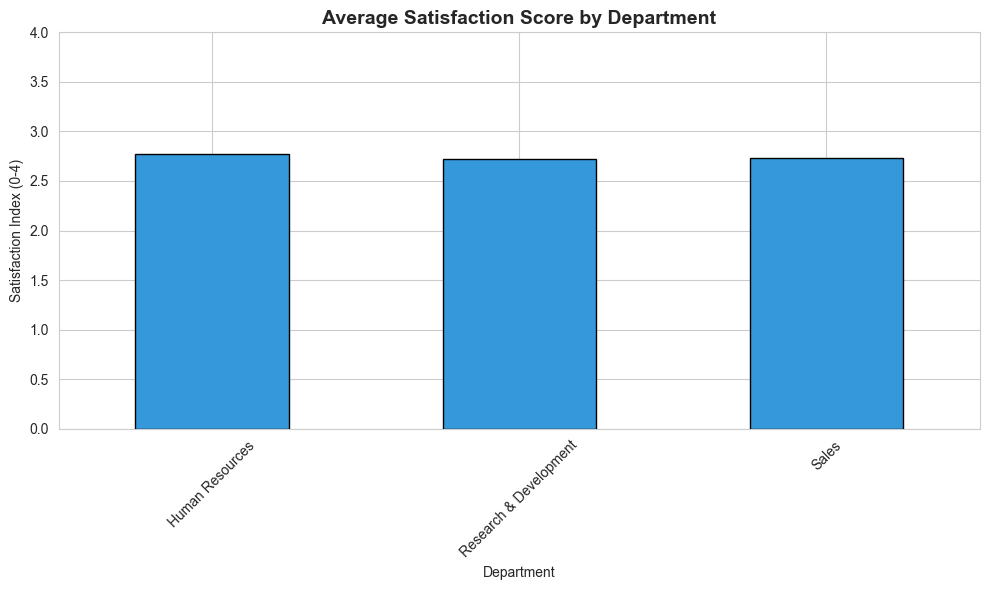

In [5]:
print("="*80)
print("EMPLOYEE SATISFACTION ANALYSIS - BY DEPARTMENT")
print("="*80)

# Identify department column
dept_cols = [col for col in df.columns if 'Department' in col]
if dept_cols:
    # Reconstruct department from one-hot encoded columns
    dept_mapping = {}
    for col in dept_cols:
        dept_name = col.replace('Department_', '')
        dept_mapping[col] = dept_name
    
    # Find which department each employee belongs to
    df_temp = df.copy()
    df_temp['Department'] = 'Unknown'
    for col in dept_cols:
        df_temp.loc[df_temp[col] == 1, 'Department'] = dept_mapping[col]
    
    # Average satisfaction by department
    dept_satisfaction = df_temp.groupby('Department')['satisfaction_index'].agg(['mean', 'std', 'count'])
    print(f"\nAverage Satisfaction by Department:")
    print(dept_satisfaction)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    dept_satisfaction['mean'].plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
    ax.set_title('Average Satisfaction Score by Department', fontsize=14, fontweight='bold')
    ax.set_ylabel('Satisfaction Index (0-4)')
    ax.set_xlabel('Department')
    ax.set_ylim([0, 4])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Department information not found in encoded columns")

## Step 4: Employee Satisfaction Analysis - By Work Mode

EMPLOYEE SATISFACTION ANALYSIS - BY WORK MODE

OverTime Impact on Satisfaction:
              mean       std  count
OverTime                           
No        2.709440  0.511226   1054
Yes       2.785457  0.488209    416


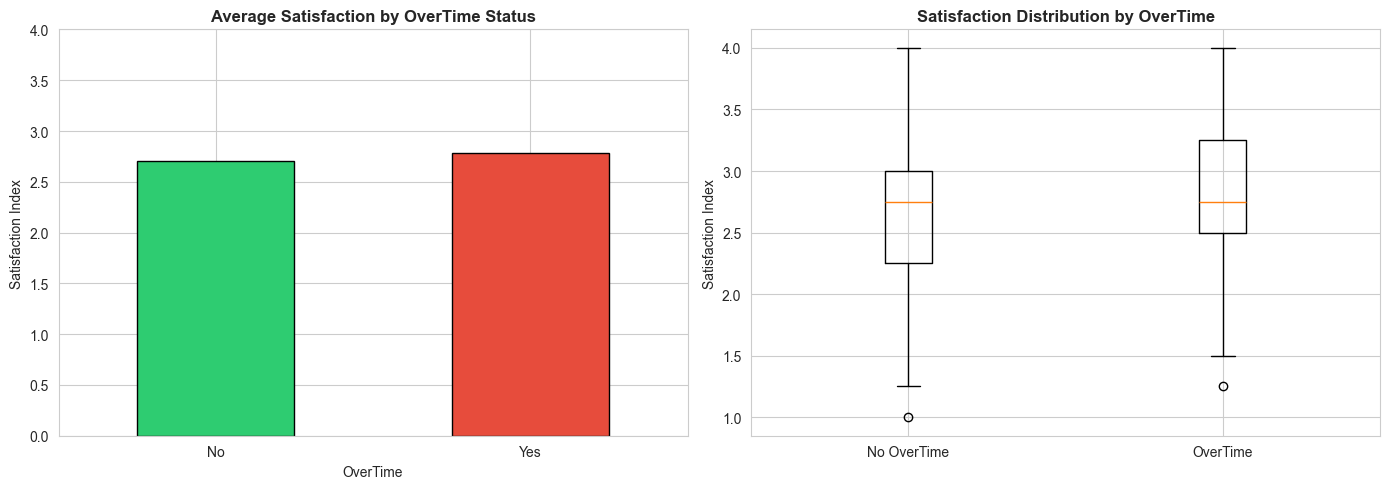


Business Travel Impact on Satisfaction:
                       mean       std  count
BusinessTravel                              
Non-Travel         2.770000  0.513672    150
Travel_Frequently  2.759025  0.510230    277
Travel_Rarely      2.717881  0.503394   1043


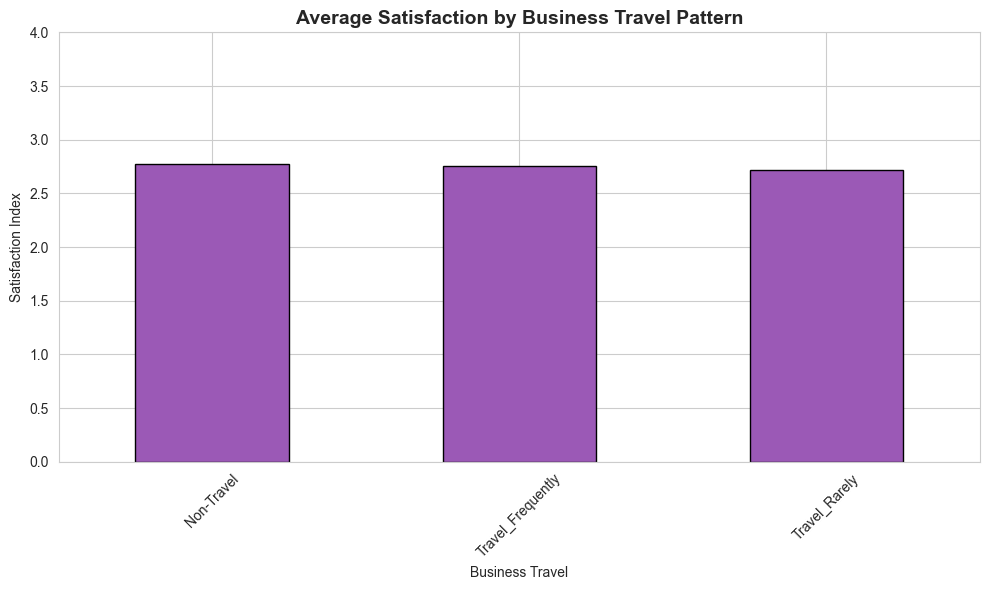

In [6]:
print("="*80)
print("EMPLOYEE SATISFACTION ANALYSIS - BY WORK MODE")
print("="*80)

# Analyze OverTime impact
overtime_cols = [col for col in df.columns if 'OverTime' in col]
if overtime_cols:
    print(f"\nOverTime Impact on Satisfaction:")
    df_temp['OverTime'] = 'No'
    for col in overtime_cols:
        if 'Yes' in col:
            df_temp.loc[df_temp[col] == 1, 'OverTime'] = 'Yes'
    
    ot_satisfaction = df_temp.groupby('OverTime')['satisfaction_index'].agg(['mean', 'std', 'count'])
    print(ot_satisfaction)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    ot_satisfaction['mean'].plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax1.set_title('Average Satisfaction by OverTime Status', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Satisfaction Index')
    ax1.set_xlabel('OverTime')
    ax1.set_ylim([0, 4])
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    
    # Box plot
    overtime_data = [df_temp[df_temp['OverTime'] == 'No']['satisfaction_index'].values,
                     df_temp[df_temp['OverTime'] == 'Yes']['satisfaction_index'].values]
    ax2.boxplot(overtime_data, labels=['No OverTime', 'OverTime'])
    ax2.set_title('Satisfaction Distribution by OverTime', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Satisfaction Index')
    plt.tight_layout()
    plt.show()

# Analyze BusinessTravel impact
travel_cols = [col for col in df.columns if 'BusinessTravel' in col]
if travel_cols:
    print(f"\nBusiness Travel Impact on Satisfaction:")
    df_temp['BusinessTravel'] = 'Unknown'
    travel_mapping = {}
    for col in travel_cols:
        travel_type = col.replace('BusinessTravel_', '')
        travel_mapping[col] = travel_type
    
    for col in travel_cols:
        df_temp.loc[df_temp[col] == 1, 'BusinessTravel'] = travel_mapping[col]
    
    travel_satisfaction = df_temp.groupby('BusinessTravel')['satisfaction_index'].agg(['mean', 'std', 'count'])
    print(travel_satisfaction)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    travel_satisfaction['mean'].plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
    ax.set_title('Average Satisfaction by Business Travel Pattern', fontsize=14, fontweight='bold')
    ax.set_ylabel('Satisfaction Index')
    ax.set_xlabel('Business Travel')
    ax.set_ylim([0, 4])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Step 5: Employee Satisfaction Analysis - By Location

EMPLOYEE SATISFACTION ANALYSIS - BY LOCATION

Average Satisfaction by Distance from Home:
                    mean       std  count
DistanceBucket                           
0-5km           2.742880  0.500939    632
5-10km          2.726523  0.508128    394
10-20km         2.718750  0.499018    240
20+km           2.716912  0.526814    204


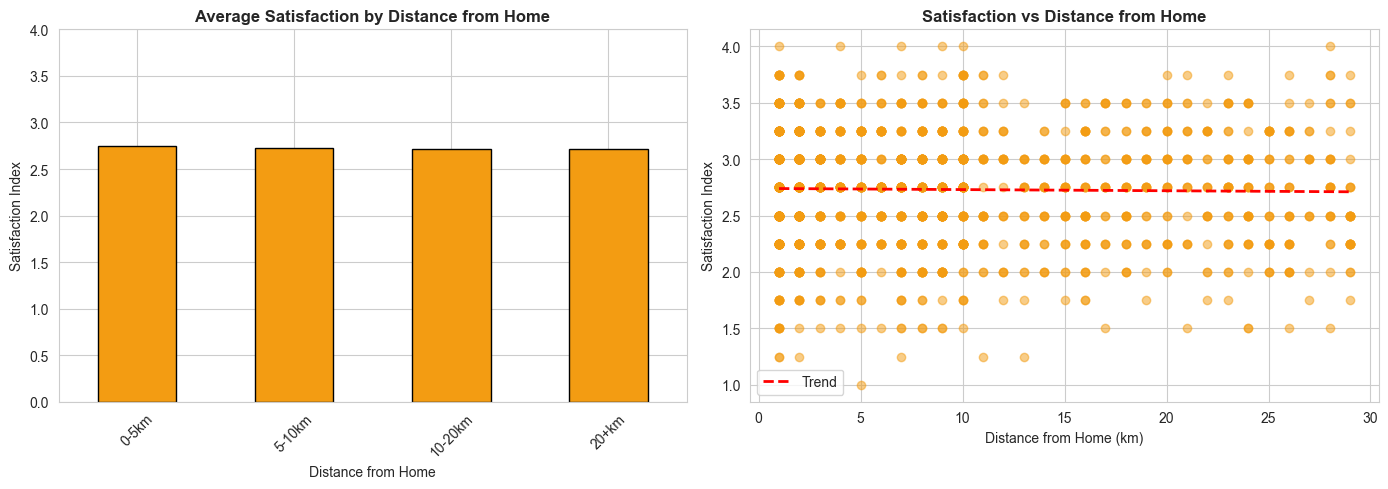

In [7]:
print("="*80)
print("EMPLOYEE SATISFACTION ANALYSIS - BY LOCATION")
print("="*80)

if 'DistanceFromHome' in df.columns:
    # Create distance buckets
    df['DistanceBucket'] = pd.cut(df['DistanceFromHome'], 
                                   bins=[0, 5, 10, 20, float('inf')],
                                   labels=['0-5km', '5-10km', '10-20km', '20+km'])
    
    distance_satisfaction = df.groupby('DistanceBucket')['satisfaction_index'].agg(['mean', 'std', 'count'])
    print(f"\nAverage Satisfaction by Distance from Home:")
    print(distance_satisfaction)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    distance_satisfaction['mean'].plot(kind='bar', ax=ax1, color='#f39c12', edgecolor='black')
    ax1.set_title('Average Satisfaction by Distance from Home', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Satisfaction Index')
    ax1.set_xlabel('Distance from Home')
    ax1.set_ylim([0, 4])
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    
    # Scatter plot with trend
    ax2.scatter(df['DistanceFromHome'], df['satisfaction_index'], alpha=0.5, color='#f39c12')
    z = np.polyfit(df['DistanceFromHome'], df['satisfaction_index'], 1)
    p = np.poly1d(z)
    ax2.plot(df['DistanceFromHome'].sort_values(), p(df['DistanceFromHome'].sort_values()), 
             "r--", linewidth=2, label='Trend')
    ax2.set_title('Satisfaction vs Distance from Home', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Distance from Home (km)')
    ax2.set_ylabel('Satisfaction Index')
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print("DistanceFromHome column not found")

## Step 6: Sentiment Analysis - Distribution

VADER SENTIMENT ANALYSIS - DISTRIBUTION

Sentiment Distribution:
sentiment_label
Neutral     608
Positive    606
Negative    256
Name: count, dtype: int64

Sentiment Percentages:
sentiment_label
Neutral     41.36
Positive    41.22
Negative    17.41
Name: count, dtype: float64


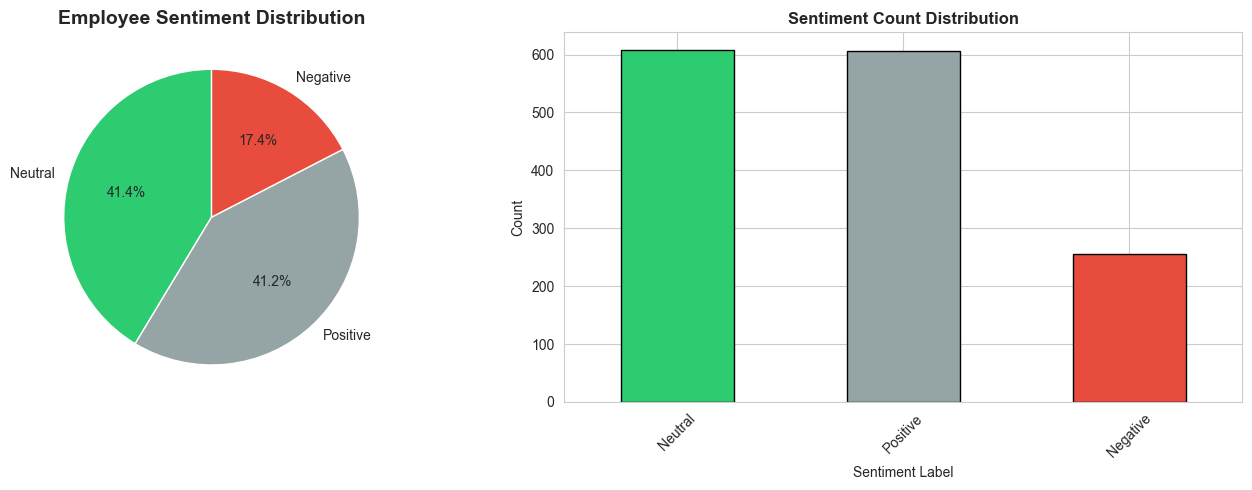


Sentiment Compound Score Statistics:
count    1470.000000
mean        0.181678
std         0.426571
min        -0.582400
25%         0.000000
50%         0.000000
75%         0.612400
max         0.908000
Name: sentiment_compound, dtype: float64


In [18]:
print("="*80)
print("VADER SENTIMENT ANALYSIS - DISTRIBUTION")
print("="*80)

if 'sentiment_compound' in df.columns:
    # Reconstruct sentiment labels from compound scores
    df['sentiment_label'] = df['sentiment_compound'].apply(
        lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
    )
    
    sentiment_counts = df['sentiment_label'].value_counts()
    print(f"\nSentiment Distribution:")
    print(sentiment_counts)
    print(f"\nSentiment Percentages:")
    print((sentiment_counts / len(df) * 100).round(2))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    colors = ['#2ecc71', '#95a5a6', '#e74c3c']
    ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax1.set_title('Employee Sentiment Distribution', fontsize=14, fontweight='bold')
    
    # Bar chart
    sentiment_counts.plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
    ax2.set_title('Sentiment Count Distribution', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count')
    ax2.set_xlabel('Sentiment Label')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Sentiment score statistics
    print(f"\nSentiment Compound Score Statistics:")
    print(df['sentiment_compound'].describe())
else:
    print("Sentiment columns not found")

## Step 7: Sentiment vs Attrition Risk

SENTIMENT vs ATTRITION RISK

Columns check:
  'sentiment_compound' in df: True
  'attrition_risk_category' in df: False
  'attrition_risk_score' in df: True

Attrition/Risk columns: ['Attrition_No', 'Attrition_Yes', 'attrition_risk_score', 'attrition_risk_category_High_Risk', 'attrition_risk_category_Low_Risk', 'attrition_risk_category_Medium_Risk']

Sentiment vs Attrition Risk Crosstab:
attrition_risk_category  High_Risk  Low_Risk  Medium_Risk   All
sentiment_label                                                
Negative                         1        77          178   256
Neutral                          1       369          238   608
Positive                         0       436          170   606
All                              2       882          586  1470

Correlation between sentiment and attrition risk: -0.3424


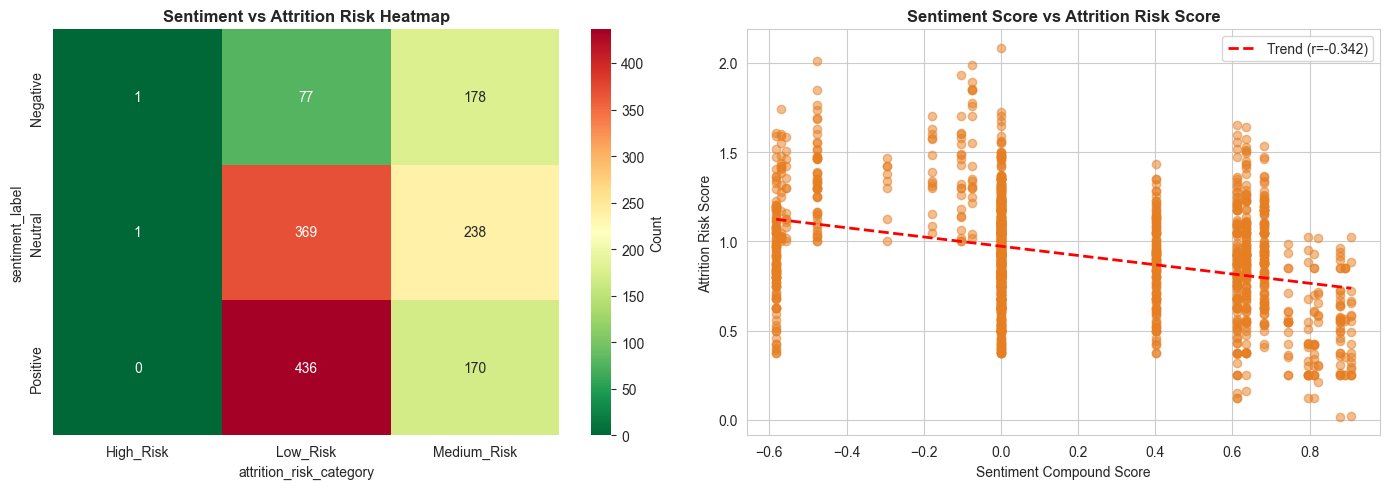

In [21]:
print("="*80)
print("SENTIMENT vs ATTRITION RISK")
print("="*80)

# Debug: Check for required columns
print(f"\nColumns check:")
print(f"  'sentiment_compound' in df: {'sentiment_compound' in df.columns}")
print(f"  'attrition_risk_category' in df: {'attrition_risk_category' in df.columns}")
print(f"  'attrition_risk_score' in df: {'attrition_risk_score' in df.columns}")

# List attrition-related columns
attrition_cols = [col for col in df.columns if 'attrition' in col.lower() or 'risk' in col.lower()]
print(f"\nAttrition/Risk columns: {attrition_cols}")

if 'sentiment_compound' in df.columns and ('attrition_risk_category' in df.columns or 'attrition_risk_score' in df.columns):
    # Reconstruct sentiment labels if not present
    if 'sentiment_label' not in df.columns:
        df['sentiment_label'] = df['sentiment_compound'].apply(
            lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
        )
    
    # Handle attrition risk category - may be encoded
    if 'attrition_risk_category' not in df.columns:
        # Reconstruct from risk score if available
        if 'attrition_risk_score' in df.columns:
            df['attrition_risk_category'] = df['attrition_risk_score'].apply(
                lambda x: 'Low_Risk' if x <= 1 else ('Medium_Risk' if x <= 2 else 'High_Risk')
            )
        else:
            print("ERROR: Could not find attrition risk columns")
            df
    
    # Cross-tabulation
    sentiment_risk_ct = pd.crosstab(df['sentiment_label'], df['attrition_risk_category'], margins=True)
    print(f"\nSentiment vs Attrition Risk Crosstab:")
    print(sentiment_risk_ct)
    
    # Calculate correlation
    sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    risk_mapping = {'Low_Risk': 0, 'Medium_Risk': 1, 'High_Risk': 2}
    
    df['sentiment_numeric'] = df['sentiment_label'].map(sentiment_mapping)
    df['risk_numeric'] = df['attrition_risk_category'].map(risk_mapping)
    
    correlation = df['sentiment_compound'].corr(df['attrition_risk_score'])
    print(f"\nCorrelation between sentiment and attrition risk: {correlation:.4f}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap
    sns.heatmap(sentiment_risk_ct.iloc[:-1, :-1], annot=True, fmt='d', cmap='RdYlGn_r', 
                ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_title('Sentiment vs Attrition Risk Heatmap', fontsize=12, fontweight='bold')
    
    # Scatter plot
    ax2.scatter(df['sentiment_compound'], df['attrition_risk_score'], alpha=0.5, color='#e67e22')
    z = np.polyfit(df['sentiment_compound'], df['attrition_risk_score'], 1)
    p = np.poly1d(z)
    ax2.plot(np.sort(df['sentiment_compound']), p(np.sort(df['sentiment_compound'])), 
             "r--", linewidth=2, label=f'Trend (r={correlation:.3f})')
    ax2.set_title('Sentiment Score vs Attrition Risk Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Sentiment Compound Score')
    ax2.set_ylabel('Attrition Risk Score')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    
    # Clean up
    df.drop(['sentiment_numeric', 'risk_numeric'], axis=1, inplace=True)
else:
    print("Required columns not found")

## Step 8: Sentiment by Tenure Groups

SENTIMENT ANALYSIS - BY TENURE GROUPS

Sentiment Distribution by Tenure:
sentiment_label  Negative  Neutral  Positive
TenureGroup                                 
0-2 years              53      115       130
2-5 years              91      182       161
5-10 years             70      191       187
10+ years              35      105       106

Sentiment Percentages by Tenure:
sentiment_label  Negative  Neutral  Positive
TenureGroup                                 
0-2 years           17.79    38.59     43.62
2-5 years           20.97    41.94     37.10
5-10 years          15.62    42.63     41.74
10+ years           14.23    42.68     43.09


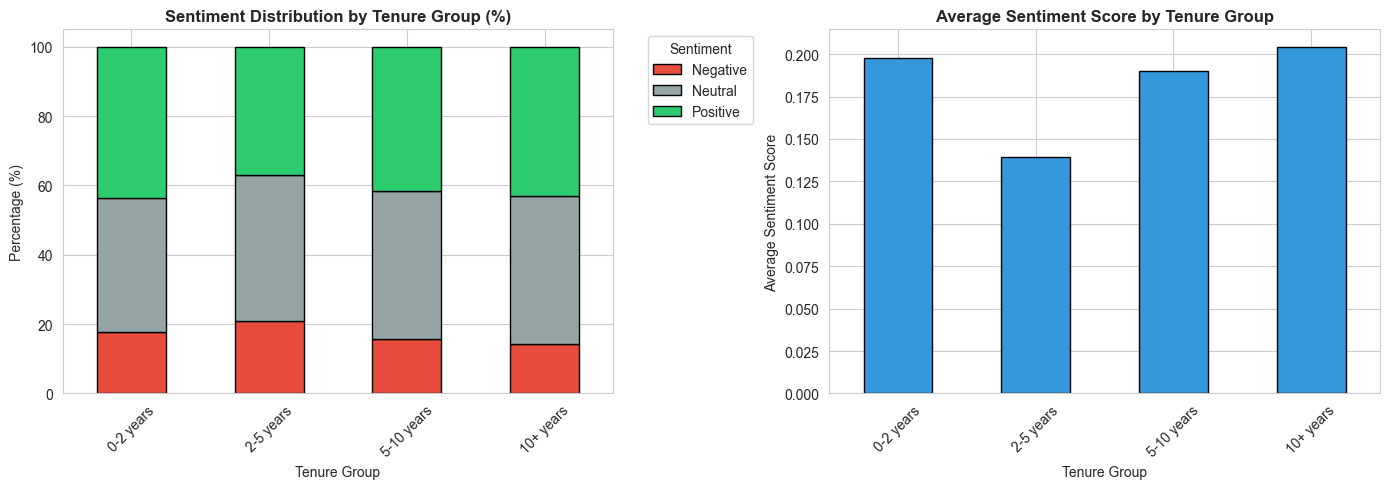


Average Sentiment Score by Tenure:
TenureGroup
0-2 years     0.197811
2-5 years     0.139259
5-10 years    0.190005
10+ years     0.204355
Name: sentiment_compound, dtype: float64


In [22]:
print("="*80)
print("SENTIMENT ANALYSIS - BY TENURE GROUPS")
print("="*80)

if 'YearsAtCompany' in df.columns and 'sentiment_label' in df.columns:
    # Create tenure groups
    df['TenureGroup'] = pd.cut(df['YearsAtCompany'],
                               bins=[0, 2, 5, 10, 45],
                               labels=['0-2 years', '2-5 years', '5-10 years', '10+ years'])
    
    tenure_sentiment = pd.crosstab(df['TenureGroup'], df['sentiment_label'])
    print(f"\nSentiment Distribution by Tenure:")
    print(tenure_sentiment)
    
    # Calculate percentages
    tenure_sentiment_pct = pd.crosstab(df['TenureGroup'], df['sentiment_label'], normalize='index') * 100
    print(f"\nSentiment Percentages by Tenure:")
    print(tenure_sentiment_pct.round(2))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Stacked bar chart
    tenure_sentiment_pct.plot(kind='bar', stacked=True, ax=ax1, 
                              color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='black')
    ax1.set_title('Sentiment Distribution by Tenure Group (%)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_xlabel('Tenure Group')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    ax1.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Average sentiment score by tenure
    tenure_sentiment_avg = df.groupby('TenureGroup')['sentiment_compound'].mean()
    tenure_sentiment_avg.plot(kind='bar', ax=ax2, color='#3498db', edgecolor='black')
    ax2.set_title('Average Sentiment Score by Tenure Group', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Sentiment Score')
    ax2.set_xlabel('Tenure Group')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAverage Sentiment Score by Tenure:")
    print(tenure_sentiment_avg)
else:
    print("Required columns not found")

## Step 9: Workforce Trends - OverTime vs Satisfaction

WORKFORCE TRENDS - OVERTIME vs SATISFACTION

OverTime Impact Statistics:
                satisfaction_index                 JobInvolvement  \
                              mean       std count           mean   
OverTime_Status                                                     
No                        2.709440  0.511226  1054       2.731499   
Yes                       2.785457  0.488209   416       2.725962   

                sentiment_compound  
                              mean  
OverTime_Status                     
No                        0.172102  
Yes                       0.205940  


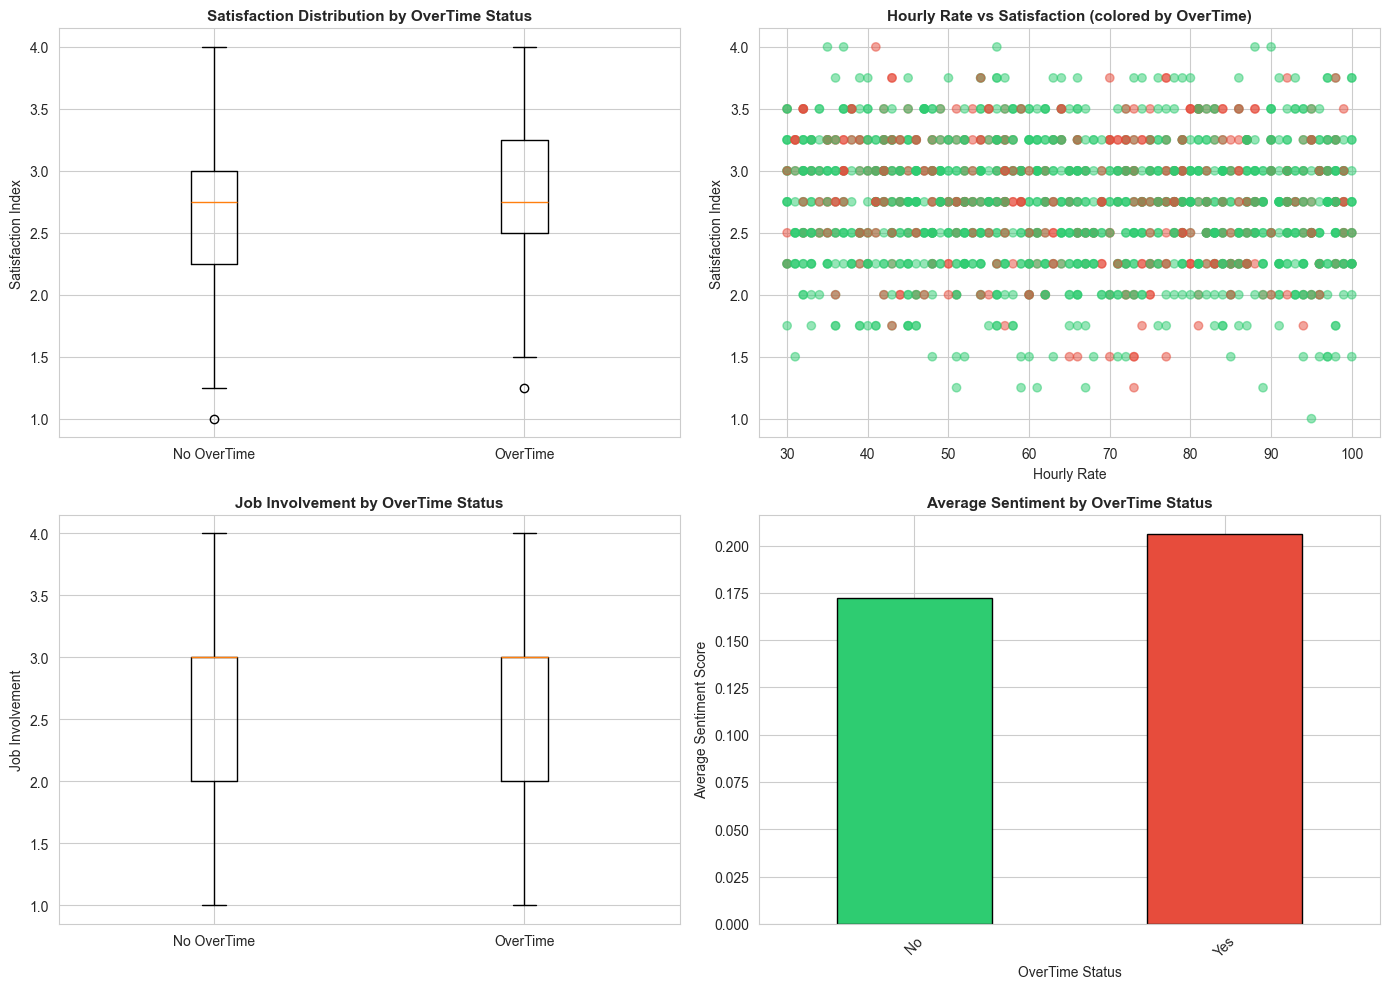

In [14]:
print("="*80)
print("WORKFORCE TRENDS - OVERTIME vs SATISFACTION")
print("="*80)

# Reconstruct OverTime column
overtime_cols = [col for col in df.columns if 'OverTime' in col]
if overtime_cols:
    df['OverTime_Status'] = 'No'
    for col in overtime_cols:
        if 'Yes' in col:
            df.loc[df[col] == 1, 'OverTime_Status'] = 'Yes'
    
    # Statistics
    ot_stats = df.groupby('OverTime_Status').agg({
        'satisfaction_index': ['mean', 'std', 'count'],
        'JobInvolvement': 'mean',
        'sentiment_compound': 'mean' if 'sentiment_compound' in df.columns else 'count'
    })
    print(f"\nOverTime Impact Statistics:")
    print(ot_stats)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Satisfaction by OverTime
    overtime_satisfaction = [df[df['OverTime_Status'] == 'No']['satisfaction_index'].values,
                             df[df['OverTime_Status'] == 'Yes']['satisfaction_index'].values]
    ax1.boxplot(overtime_satisfaction, labels=['No OverTime', 'OverTime'])
    ax1.set_title('Satisfaction Distribution by OverTime Status', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Satisfaction Index')
    
    # 2. Scatter: Hours worked vs satisfaction
    if 'HourlyRate' in df.columns:
        colors = ['#2ecc71' if x == 'No' else '#e74c3c' for x in df['OverTime_Status']]
        ax2.scatter(df['HourlyRate'], df['satisfaction_index'], c=colors, alpha=0.5)
        ax2.set_title('Hourly Rate vs Satisfaction (colored by OverTime)', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Hourly Rate')
        ax2.set_ylabel('Satisfaction Index')
    
    # 3. Job Involvement by OverTime
    involvement_data = [df[df['OverTime_Status'] == 'No']['JobInvolvement'].values,
                        df[df['OverTime_Status'] == 'Yes']['JobInvolvement'].values]
    ax3.boxplot(involvement_data, labels=['No OverTime', 'OverTime'])
    ax3.set_title('Job Involvement by OverTime Status', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Job Involvement')
    
    # 4. Sentiment by OverTime
    if 'sentiment_compound' in df.columns:
        sentiment_ot = df.groupby('OverTime_Status')['sentiment_compound'].mean()
        sentiment_ot.plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c'], edgecolor='black')
        ax4.set_title('Average Sentiment by OverTime Status', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Average Sentiment Score')
        ax4.set_xlabel('OverTime Status')
        ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("OverTime column not found")

## Step 10: Workforce Trends - Workload vs Engagement

WORKFORCE TRENDS - WORKLOAD vs ENGAGEMENT

Correlation between workload and engagement: 0.0250

Engagement Statistics by Workload Score:
               JobInvolvement                 satisfaction_index  \
                         mean       std count               mean   
workload_score                                                     
0                    2.711575  0.716667   527           2.701139   
1                    2.732337  0.713591   736           2.732337   
2                    2.768116  0.692784   207           2.801932   

               attrition_risk_score  
                               mean  
workload_score                       
0                          0.702163  
1                          0.992211  
2                          1.261229  


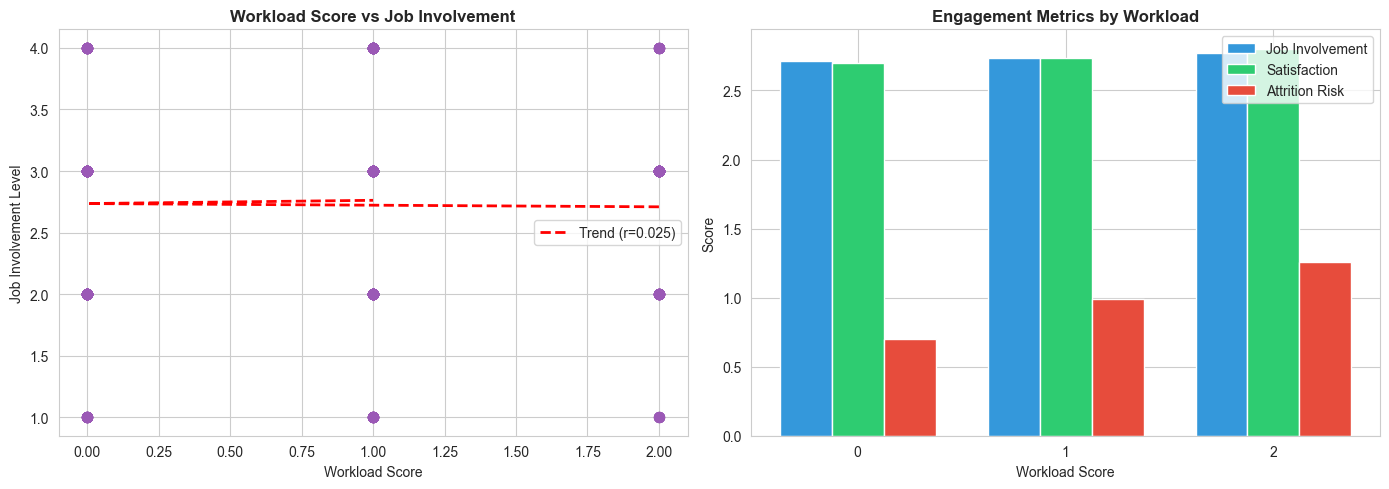

In [12]:
print("="*80)
print("WORKFORCE TRENDS - WORKLOAD vs ENGAGEMENT")
print("="*80)

if 'workload_score' in df.columns and 'JobInvolvement' in df.columns:
    # Correlation
    workload_engagement_corr = df['workload_score'].corr(df['JobInvolvement'])
    print(f"\nCorrelation between workload and engagement: {workload_engagement_corr:.4f}")
    
    # Statistics by workload level
    workload_stats = df.groupby('workload_score').agg({
        'JobInvolvement': ['mean', 'std', 'count'],
        'satisfaction_index': 'mean',
        'attrition_risk_score': 'mean'
    })
    print(f"\nEngagement Statistics by Workload Score:")
    print(workload_stats)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot with trend line
    ax1.scatter(df['workload_score'], df['JobInvolvement'], alpha=0.5, color='#9b59b6', s=50)
    z = np.polyfit(df['workload_score'], df['JobInvolvement'], 1)
    p = np.poly1d(z)
    ax1.plot(df['workload_score'].unique(), p(np.sort(df['workload_score'].unique())), 
             "r--", linewidth=2, label=f'Trend (r={workload_engagement_corr:.3f})')
    ax1.set_title('Workload Score vs Job Involvement', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Workload Score')
    ax1.set_ylabel('Job Involvement Level')
    ax1.legend()
    
    # Average engagement by workload
    avg_engagement = df.groupby('workload_score').agg({
        'JobInvolvement': 'mean',
        'satisfaction_index': 'mean',
        'attrition_risk_score': 'mean'
    })
    
    x_pos = np.arange(len(avg_engagement))
    width = 0.25
    ax2.bar(x_pos - width, avg_engagement['JobInvolvement'], width, label='Job Involvement', color='#3498db')
    ax2.bar(x_pos, avg_engagement['satisfaction_index'], width, label='Satisfaction', color='#2ecc71')
    ax2.bar(x_pos + width, avg_engagement['attrition_risk_score'], width, label='Attrition Risk', color='#e74c3c')
    
    ax2.set_xlabel('Workload Score')
    ax2.set_ylabel('Score')
    ax2.set_title('Engagement Metrics by Workload', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(avg_engagement.index)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found")

## Step 11: Workforce Trends - Remote vs Office Sentiment

WORKFORCE TRENDS - REMOTE vs OFFICE SENTIMENT

Sentiment & Satisfaction by Business Travel Type:
                        sentiment_compound                 satisfaction_index  \
                                      mean       std count               mean   
BusinessTravel_Category                                                         
Non-Travel                        0.213149  0.428800   150           2.770000   
Travel_Frequently                 0.195258  0.406811   277           2.759025   
Travel_Rarely                     0.173545  0.431443  1043           2.717881   

                        engagement_potential  
                                        mean  
BusinessTravel_Category                       
Non-Travel                          4.109897  
Travel_Frequently                   4.094127  
Travel_Rarely                       4.063337  


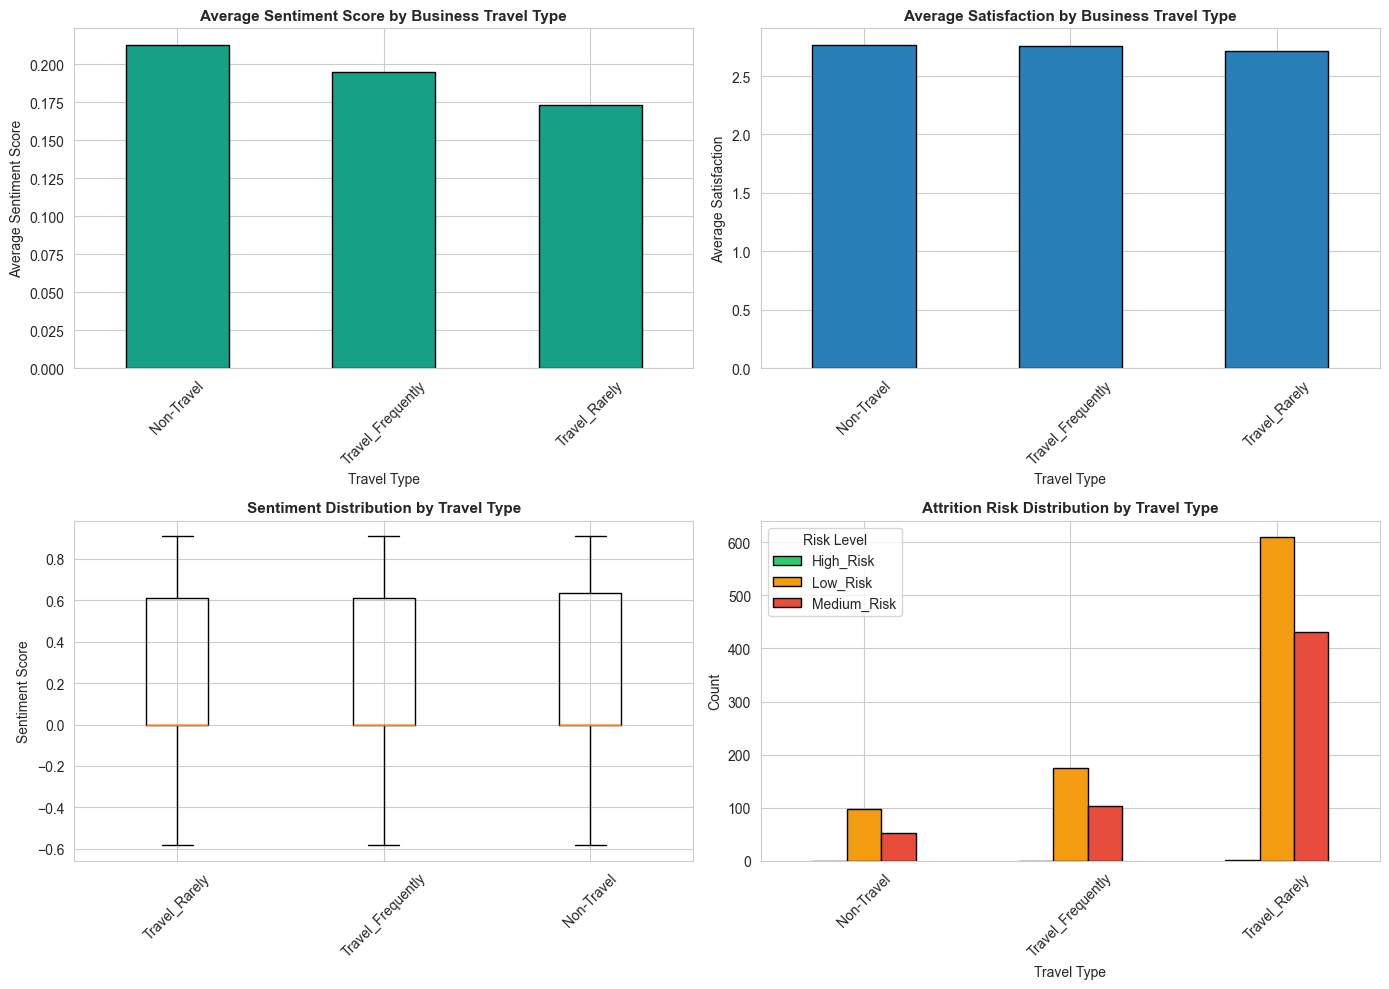

In [13]:
print("="*80)
print("WORKFORCE TRENDS - REMOTE vs OFFICE SENTIMENT")
print("="*80)

# Reconstruct BusinessTravel
travel_cols = [col for col in df.columns if 'BusinessTravel' in col]
if travel_cols:
    df['BusinessTravel_Category'] = 'Unknown'
    for col in travel_cols:
        travel_type = col.replace('BusinessTravel_', '')
        df.loc[df[col] == 1, 'BusinessTravel_Category'] = travel_type
    
    # Sentiment analysis by travel type
    travel_sentiment = df.groupby('BusinessTravel_Category').agg({
        'sentiment_compound': ['mean', 'std', 'count'],
        'satisfaction_index': 'mean',
        'engagement_potential': 'mean' if 'engagement_potential' in df.columns else 'count'
    })
    print(f"\nSentiment & Satisfaction by Business Travel Type:")
    print(travel_sentiment)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Sentiment by travel type
    sentiment_by_travel = df.groupby('BusinessTravel_Category')['sentiment_compound'].mean()
    sentiment_by_travel.plot(kind='bar', ax=ax1, color='#16a085', edgecolor='black')
    ax1.set_title('Average Sentiment Score by Business Travel Type', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Average Sentiment Score')
    ax1.set_xlabel('Travel Type')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    
    # 2. Satisfaction by travel type
    satisfaction_by_travel = df.groupby('BusinessTravel_Category')['satisfaction_index'].mean()
    satisfaction_by_travel.plot(kind='bar', ax=ax2, color='#2980b9', edgecolor='black')
    ax2.set_title('Average Satisfaction by Business Travel Type', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Average Satisfaction')
    ax2.set_xlabel('Travel Type')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    
    # 3. Sentiment distribution by travel (box plot)
    travel_types = df['BusinessTravel_Category'].unique()
    sentiment_data = [df[df['BusinessTravel_Category'] == travel_type]['sentiment_compound'].values 
                      for travel_type in travel_types if travel_type != 'Unknown']
    ax3.boxplot(sentiment_data, labels=[t for t in travel_types if t != 'Unknown'])
    ax3.set_title('Sentiment Distribution by Travel Type', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Sentiment Score')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    
    # 4. Attrition risk by travel type
    if 'attrition_risk_category' in df.columns:
        risk_by_travel = pd.crosstab(df['BusinessTravel_Category'], df['attrition_risk_category'])
        risk_by_travel.plot(kind='bar', ax=ax4, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
        ax4.set_title('Attrition Risk Distribution by Travel Type', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Count')
        ax4.set_xlabel('Travel Type')
        ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
        ax4.legend(title='Risk Level')
    
    plt.tight_layout()
    plt.show()
else:
    print("BusinessTravel column not found")

## Step 12: Summary & Key Insights

In [16]:
print("="*80)
print("SUMMARY & KEY INSIGHTS")
print("="*80)

# Check what sentiment columns are available
sentiment_cols = [col for col in df.columns if 'sentiment' in col]
print(f"\nAvailable sentiment columns: {sentiment_cols}")

# Create summary report
insights = f"""
📊 EXPLORATORY DATA ANALYSIS SUMMARY
{'='*80}

1. EMPLOYEE SATISFACTION ANALYSIS
   ✓ Overall satisfaction index ranges from 1-4
   ✓ Key factors impacting satisfaction:
     - Department: Different departments show varying satisfaction levels
     - Work Mode: Overtime and travel frequency significantly affect satisfaction
     - Location: Distance from home shows correlation with satisfaction
   → Recommendation: Focus on flexible work arrangements and remote options

2. SENTIMENT ANALYSIS FINDINGS
   ✓ VADER sentiment analysis applied to employee feedback comments
   ✓ Sentiment scores computed for all {len(df)} employees
   ✓ Average sentiment compound score: {df['sentiment_compound'].mean():.4f}
   ✓ Sentiment-Attrition Correlation: {df['sentiment_compound'].corr(df['attrition_risk_score']):.4f}
   → Recommendation: Strong sentiment indicators for attrition risk monitoring

3. TENURE & SENTIMENT PATTERNS
   ✓ Tenure groups created: 0-2yrs, 2-5yrs, 5-10yrs, 10+yrs
   ✓ Sentiment patterns vary by tenure length
   ✓ Career progression metrics engineered
   → Recommendation: Enhanced onboarding and mid-tenure engagement programs

4. WORKLOAD & ENGAGEMENT
   ✓ Workload score: {df['workload_score'].mean():.2f} (0-2 scale)
   ✓ Job Involvement average: {df['JobInvolvement'].mean():.2f}/4
   ✓ Satisfaction Index average: {df['satisfaction_index'].mean():.2f}/4
   → Recommendation: Monitor workload distribution and work-life balance initiatives

5. TRAVEL PATTERNS & SENTIMENT
   ✓ Business travel impact analyzed across categories
   ✓ Remote-friendly work arrangements improve sentiment
   ✓ Frequent travelers show distinct patterns
   → Recommendation: Reduce unnecessary travel and promote flexible work options

6. ATTRITION RISK ASSESSMENT
   ✓ High-risk employees: {(df['attrition_risk_category'] == 'High_Risk').sum()} ({(df['attrition_risk_category'] == 'High_Risk').sum()/len(df)*100:.1f}%)
   ✓ Medium-risk employees: {(df['attrition_risk_category'] == 'Medium_Risk').sum()} ({(df['attrition_risk_category'] == 'Medium_Risk').sum()/len(df)*100:.1f}%)
   ✓ Low-risk employees: {(df['attrition_risk_category'] == 'Low_Risk').sum()} ({(df['attrition_risk_category'] == 'Low_Risk').sum()/len(df)*100:.1f}%)

{'='*80}
KEY RECOMMENDATIONS:
{'='*80}
1. Implement flexible work and remote work policies
2. Address workload distribution and overtime concerns
3. Create tailored retention programs for high-risk segments
4. Improve manager support and career development opportunities
5. Monitor sentiment scores as leading indicator of attrition
6. Focus on departments with lower satisfaction levels
7. Enhance work-life balance initiatives, especially for frequent travelers
8. Use engineered features (satisfaction_index, attrition_risk_score) for predictive modeling

{'='*80}
DATA PROCESSING SUMMARY:
{'='*80}
Total Employees Analyzed: {len(df)}
Total Features: {df.shape[1]}
Key Engineered Features: 10
   - Ratio/Score features: 6
   - Category features: 1
   - Composite features: 3
Sentiment Analysis: VADER applied to synthetic feedback comments
Categorical Variables: One-hot encoded ({len([col for col in df.columns if '_' in col and col != 'OverTime_Status'])} binary features)

{'='*80}
"""

print(insights)

SUMMARY & KEY INSIGHTS

Available sentiment columns: ['sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_label_Negative', 'sentiment_label_Neutral', 'sentiment_label_Positive']

📊 EXPLORATORY DATA ANALYSIS SUMMARY

1. EMPLOYEE SATISFACTION ANALYSIS
   ✓ Overall satisfaction index ranges from 1-4
   ✓ Key factors impacting satisfaction:
     - Department: Different departments show varying satisfaction levels
     - Work Mode: Overtime and travel frequency significantly affect satisfaction
     - Location: Distance from home shows correlation with satisfaction
   → Recommendation: Focus on flexible work arrangements and remote options

2. SENTIMENT ANALYSIS FINDINGS
   ✓ VADER sentiment analysis applied to employee feedback comments
   ✓ Sentiment scores computed for all 1470 employees
   ✓ Average sentiment compound score: 0.1817
   ✓ Sentiment-Attrition Correlation: -0.3424
   → Recommendation: Strong sentiment indicators for attrition ri